# 스트리밍 알고리즘 2종 구현 및 정확도·메모리 트레이드오프 분석

**학번/이름:** 2353683 / 김남규  
**데이터셋:** MovieLens 1M (사용자-영화 평점 스트림, 1,000,209건)  
**제출일:** 2026-06-14

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import math
import hashlib
import random
import time
import sys
import os
import zipfile
import urllib.request
from collections import defaultdict

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('라이브러리 로드 완료')
print(f'Python {sys.version.split()[0]} | numpy {np.__version__} | matplotlib {matplotlib.__version__}')

라이브러리 로드 완료
Python 3.14.3 | numpy 2.4.6 | matplotlib 3.11.0


---
## STEP 01. 데이터 준비

### 1-1. 데이터셋 소개

**MovieLens 1M**은 GroupLens Research에서 공개한 협업 필터링 벤치마크 데이터셋입니다.  
6,040명의 사용자가 3,706편의 영화에 남긴 평점 기록 1,000,209건으로 구성되며,  
스트리밍 형태(한 줄씩 순차 처리)로 읽어 알고리즘에 공급합니다.

### 1-2. 컬럼 설명

| 컬럼 | 타입 | 설명 |
|------|------|------|
| UserID | int | 사용자 고유 ID (1 ~ 6,040) |
| MovieID | int | 영화 고유 ID (1 ~ 3,952) |
| Rating | float | 평점 (1 ~ 5, 0.5 단위) |
| Timestamp | int | 평점 기록 시각 (Unix timestamp) |

In [2]:
DATA_DIR = os.path.join(os.getcwd(), 'data')
RATINGS_PATH = os.path.join(DATA_DIR, 'ratings.dat')
os.makedirs(DATA_DIR, exist_ok=True)

def download_movielens():
    url = 'https://files.grouplens.org/datasets/movielens/ml-1m.zip'
    zip_path = os.path.join(DATA_DIR, 'ml-1m.zip')
    print('MovieLens 1M 다운로드 중...')
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(DATA_DIR)
    import shutil
    shutil.copy(os.path.join(DATA_DIR, 'ml-1m', 'ratings.dat'), RATINGS_PATH)
    print('다운로드 완료!')

def stream_ratings(path):
    """ratings.dat 를 한 줄씩 yield — 전체 메모리 적재 없음"""
    with open(path, 'r', encoding='latin-1') as f:
        for line in f:
            parts = line.strip().split('::')
            if len(parts) == 4:
                yield {'user_id': parts[0], 'movie_id': parts[1],
                       'rating': float(parts[2]), 'timestamp': int(parts[3])}

if not os.path.exists(RATINGS_PATH):
    download_movielens()

with open(RATINGS_PATH, 'r', encoding='latin-1') as f:
    TOTAL_RECORDS = sum(1 for _ in f)

print('=== 데이터셋 기본 정보 ===')
print(f'파일 경로  : {RATINGS_PATH}')
print(f'총 레코드  : {TOTAL_RECORDS:,}건')
print(f'처리 방식  : 제너레이터 (한 줄씩 스트림 처리)')
print()
print('샘플 레코드 (첫 5건):')
for i, row in enumerate(stream_ratings(RATINGS_PATH)):
    print(f'  {row}')
    if i >= 4: break

=== 데이터셋 기본 정보 ===
파일 경로  : C:\Users\rlask\Desktop\data\ratings.dat
총 레코드  : 1,000,209건
처리 방식  : 제너레이터 (한 줄씩 스트림 처리)

샘플 레코드 (첫 5건):
  {'user_id': '1', 'movie_id': '1193', 'rating': 5.0, 'timestamp': 978300760}
  {'user_id': '1', 'movie_id': '661', 'rating': 3.0, 'timestamp': 978302109}
  {'user_id': '1', 'movie_id': '914', 'rating': 3.0, 'timestamp': 978301968}
  {'user_id': '1', 'movie_id': '3408', 'rating': 4.0, 'timestamp': 978300275}
  {'user_id': '1', 'movie_id': '2355', 'rating': 5.0, 'timestamp': 978824291}


---
## STEP 02. 알고리즘 구현

### 2-1. Bloom Filter

원소 포함 여부를 근사 판정하는 확률적 자료구조입니다.  
- **False Negative 불가**, False Positive만 발생  
- 최적 파라미터: $m = -n \ln p / (\ln 2)^2$, $k = (m/n) \ln 2$

In [3]:
class BloomFilter:
    def __init__(self, n, fp_rate=0.01):
        self.fp_rate = fp_rate
        self.n = n
        self.m = int(-n * math.log(fp_rate) / (math.log(2) ** 2))
        self.k = max(1, int(round(self.m / n * math.log(2))))
        self.bit_array = bytearray(math.ceil(self.m / 8))

    def _hash(self, item, seed):
        return int(hashlib.md5(f'{item}{seed}'.encode()).hexdigest(), 16) % self.m

    def add(self, item):
        for i in range(self.k):
            idx = self._hash(item, i)
            self.bit_array[idx // 8] |= (1 << (idx % 8))

    def contains(self, item):
        for i in range(self.k):
            idx = self._hash(item, i)
            if not (self.bit_array[idx // 8] & (1 << (idx % 8))):
                return False
        return True

    def memory_bytes(self):
        return sys.getsizeof(self.bit_array)


class BloomFilterManual:
    """파라미터 비교 실험용: m, k 직접 지정"""
    def __init__(self, m, k):
        self.m, self.k = m, k
        self.bit_array = bytearray(math.ceil(m / 8))

    def _hash(self, item, seed):
        return int(hashlib.md5(f'{item}{seed}'.encode()).hexdigest(), 16) % self.m

    def add(self, item):
        for i in range(self.k):
            idx = self._hash(item, i)
            self.bit_array[idx // 8] |= (1 << (idx % 8))

    def contains(self, item):
        for i in range(self.k):
            idx = self._hash(item, i)
            if not (self.bit_array[idx // 8] & (1 << (idx % 8))):
                return False
        return True

    def memory_bytes(self):
        return sys.getsizeof(self.bit_array)

    def theoretical_fp_rate(self, n):
        return (1 - math.exp(-self.k * n / self.m)) ** self.k if n > 0 else 0.0


# 동작 확인
_bf = BloomFilter(n=1000, fp_rate=0.01)
_bf.add('apple'); _bf.add('banana')
print(f"'apple' 포함: {_bf.contains('apple')} (예상: True)")
print(f"'grape' 포함: {_bf.contains('grape')} (예상: False)")
print(f'최적 m={_bf.m}, k={_bf.k}, 메모리={_bf.memory_bytes()} bytes')

'apple' 포함: True (예상: True)
'grape' 포함: False (예상: False)
최적 m=9585, k=7, 메모리=1256 bytes


### 2-2. Count-Min Sketch

항목별 빈도를 근사 추정하는 자료구조입니다.  
- depth × width 카운터 배열, depth 개의 독립 해시 함수 사용  
- 조회 시 **최솟값 반환** — 항상 과추정, 과소추정 없음

In [4]:
class CountMinSketch:
    def __init__(self, width=1000, depth=5):
        self.width, self.depth = width, depth
        self.table = [[0] * width for _ in range(depth)]
        self.seeds = [random.randint(1, 10**9) for _ in range(depth)]
        self.total = 0

    def _hash(self, item, row):
        return int(hashlib.md5(f'{item}{self.seeds[row]}'.encode()).hexdigest(), 16) % self.width

    def add(self, item, count=1):
        for row in range(self.depth):
            self.table[row][self._hash(item, row)] += count
        self.total += count

    def estimate(self, item):
        return min(self.table[row][self._hash(item, row)] for row in range(self.depth))

    def memory_bytes(self):
        return self.width * self.depth * 8  # int64 기준


# 동작 확인
_cms = CountMinSketch(width=500, depth=5)
for _ in range(100): _cms.add('apple')
for _ in range(50):  _cms.add('banana')
print(f"'apple' 추정 빈도: {_cms.estimate('apple')} (실제: 100)")
print(f"'banana' 추정 빈도: {_cms.estimate('banana')} (실제: 50)")
print(f'메모리: {_cms.memory_bytes()} bytes')

'apple' 추정 빈도: 100 (실제: 100)
'banana' 추정 빈도: 50 (실제: 50)
메모리: 20000 bytes


### 2-3. HyperLogLog (보너스)

고유 원소 수(카디널리티)를 극소 메모리로 추정합니다.  
- $2^b$ 개 버킷에 해시값의 선두 0비트 최댓값 저장  
- 표준 오차: $1.04 / \sqrt{m}$, 소·대 범위 보정 적용

In [5]:
class HyperLogLog:
    def __init__(self, b=10):
        self.b = b
        self.m = 1 << b
        self.registers = [0] * self.m
        if   self.m == 16: self.alpha = 0.673
        elif self.m == 32: self.alpha = 0.697
        elif self.m == 64: self.alpha = 0.709
        else:              self.alpha = 0.7213 / (1 + 1.079 / self.m)

    def _hash(self, item):
        return int(hashlib.sha256(str(item).encode()).hexdigest(), 16)

    def _rho(self, w):
        return (64 - self.b + 1) if w == 0 else (w & -w).bit_length()

    def add(self, item):
        x = self._hash(item)
        j = x & (self.m - 1)
        self.registers[j] = max(self.registers[j], self._rho(x >> self.b))

    def count(self):
        Z = sum(2.0 ** (-r) for r in self.registers)
        E = self.alpha * (self.m ** 2) / Z
        if E <= 2.5 * self.m:
            V = self.registers.count(0)
            if V > 0: E = self.m * math.log(self.m / V)
        elif E > (1.0 / 30.0) * (2 ** 32):
            E = -(2 ** 32) * math.log(1 - E / (2 ** 32))
        return int(E)

    def memory_bytes(self):
        return sys.getsizeof(self.registers)


# 동작 확인
_hll = HyperLogLog(b=10)
for i in range(1000): _hll.add(f'user_{i}')
print(f'고유 원소 추정: {_hll.count()} (실제: 1000)')
print(f'상대 오차: {abs(_hll.count()-1000)/1000*100:.2f}%')
print(f'메모리: {_hll.memory_bytes()} bytes')

고유 원소 추정: 999 (실제: 1000)
상대 오차: 0.10%
메모리: 8248 bytes


---
## STEP 03. Ground Truth 계산

스트리밍 알고리즘 결과와 비교하기 위한 정확한 기준값을 계산합니다.  
**전체 데이터를 메모리에 적재하지 않고** 스트림을 1회 순회하여 집합·빈도만 저장합니다.

| Ground Truth | 자료구조 | 용도 |
|---|---|---|
| 고유 영화 집합 | Python `set` | Bloom Filter 비교 |
| 영화별 정확한 빈도 | Python `defaultdict` | Count-Min Sketch 비교 |
| 고유 영화 수 | int | HyperLogLog 비교 |

In [6]:
print('Ground Truth 계산 중... (전체 데이터 1회 순회, 집합·빈도만 저장)')
t0 = time.perf_counter()

exact_set  = set()
exact_freq = defaultdict(int)

for row in stream_ratings(RATINGS_PATH):
    movie_id = row['movie_id']
    exact_set.add(movie_id)
    exact_freq[movie_id] += 1

elapsed = time.perf_counter() - t0
UNIQUE_MOVIES = len(exact_set)

print(f'완료 ({elapsed:.2f}초)')
print()
print('=== Ground Truth 요약 ===')
print(f'총 레코드       : {TOTAL_RECORDS:>10,}건')
print(f'고유 영화 수    : {UNIQUE_MOVIES:>10,}편')
print(f'고유 사용자 수  : 약       6,040명')

top10 = sorted(exact_freq.items(), key=lambda x: -x[1])[:10]
print()
print('상위 10개 영화 빈도:')
print(f"  {'MovieID':>8}  {'평점 수':>8}  {'비율':>6}")
for mid, cnt in top10:
    print(f'  {mid:>8}  {cnt:>8,}  {cnt/TOTAL_RECORDS*100:>5.2f}%')

gt_set_kb  = sys.getsizeof(exact_set)  / 1024
gt_dict_kb = sys.getsizeof(exact_freq) / 1024
print()
print('Ground Truth 메모리:')
print(f'  exact_set  (Python set) : {gt_set_kb:.1f} KB')
print(f'  exact_freq (Python dict): {gt_dict_kb:.1f} KB')

Ground Truth 계산 중... (전체 데이터 1회 순회, 집합·빈도만 저장)


완료 (0.87초)

=== Ground Truth 요약 ===
총 레코드       :  1,000,209건
고유 영화 수    :      3,706편
고유 사용자 수  : 약       6,040명

상위 10개 영화 빈도:
   MovieID      평점 수      비율
      2858     3,428   0.34%
       260     2,991   0.30%
      1196     2,990   0.30%
      1210     2,883   0.29%
       480     2,672   0.27%
      2028     2,653   0.27%
       589     2,649   0.26%
      2571     2,590   0.26%
      1270     2,583   0.26%
       593     2,578   0.26%

Ground Truth 메모리:
  exact_set  (Python set) : 128.2 KB
  exact_freq (Python dict): 101.4 KB


In [7]:
# 파라미터 비교 실험은 동일 데이터를 10회 이상 반복 처리해야 하므로
# movie_id 문자열만 캐시 — 전체 row dict 를 유지하지 않아 메모리 최소화
# (메인 알고리즘 실험 STEP 04~06 은 파일 스트림을 직접 사용)
print('파라미터 비교 실험용 movie_id 캐시 생성 중...')
t0 = time.perf_counter()
movie_id_cache = [row['movie_id'] for row in stream_ratings(RATINGS_PATH)]
print(f'완료 ({time.perf_counter()-t0:.2f}초)  '
      f'캐시 크기: {sys.getsizeof(movie_id_cache)//1024:.0f} KB  '
      f'항목 수: {len(movie_id_cache):,}건')

파라미터 비교 실험용 movie_id 캐시 생성 중...


완료 (0.59초)  캐시 크기: 8250 KB  항목 수: 1,000,209건


---
## STEP 04. Bloom Filter 실험

### 4-1. 단일 실험 (목표 FP율 1%)

In [8]:
print('=== Bloom Filter 실험 (파일 스트림 직접 사용) ===')

bf = BloomFilter(n=UNIQUE_MOVIES, fp_rate=0.01)

t0 = time.perf_counter()
for row in stream_ratings(RATINGS_PATH):
    bf.add(row['movie_id'])
bf_time = time.perf_counter() - t0

test_pos = list(exact_set)[:2000]
test_neg = [f'FAKE_{i}' for i in range(2000)]

tp = sum(1 for x in test_pos if bf.contains(x))
fn = len(test_pos) - tp
fp = sum(1 for x in test_neg if bf.contains(x))
tn = len(test_neg) - fp

fp_rate_actual = fp / len(test_neg)
fn_rate_actual = fn / len(test_pos)

print()
print('[파라미터]')
print(f'  비트 배열 크기 m = {bf.m:,} bits ({bf.m//8//1024:.1f} KB)')
print(f'  해시 함수 수   k = {bf.k}')
print(f'  목표 FP율        = 1.00%')
print()
print('[정확도]')
print(f'  TP (있는 것 → True) : {tp:,} / 2,000')
print(f'  FN (있는 것 → False): {fn:,} / 2,000  ← 항상 0')
print(f'  FP (없는 것 → True) : {fp:,} / 2,000')
print(f'  TN (없는 것 → False): {tn:,} / 2,000')
print(f'  실제 FP율: {fp_rate_actual*100:.2f}%  (목표: 1.00%)')
print(f'  실제 FN율: {fn_rate_actual*100:.2f}%  (항상 0%)')
print()
print('[성능]')
print(f'  처리 시간: {bf_time:.3f}초')
print(f'  처리량   : {TOTAL_RECORDS/bf_time:,.0f} items/sec')
print(f'  메모리   : {bf.memory_bytes()/1024:.1f} KB  (정확한 집합 {gt_set_kb:.1f} KB 대비)')

BF_RESULT = {
    'm': bf.m, 'k': bf.k,
    'fp_rate': fp_rate_actual, 'fn_rate': fn_rate_actual,
    'time': bf_time, 'memory_kb': bf.memory_bytes()/1024,
    'throughput': TOTAL_RECORDS/bf_time
}

=== Bloom Filter 실험 (파일 스트림 직접 사용) ===



[파라미터]
  비트 배열 크기 m = 35,522 bits (4.0 KB)
  해시 함수 수   k = 7
  목표 FP율        = 1.00%

[정확도]
  TP (있는 것 → True) : 2,000 / 2,000
  FN (있는 것 → False): 0 / 2,000  ← 항상 0
  FP (없는 것 → True) : 17 / 2,000
  TN (없는 것 → False): 1,983 / 2,000
  실제 FP율: 0.85%  (목표: 1.00%)
  실제 FN율: 0.00%  (항상 0%)

[성능]
  처리 시간: 8.875초
  처리량   : 112,704 items/sec
  메모리   : 4.4 KB  (정확한 집합 128.2 KB 대비)


---
## STEP 05. Count-Min Sketch 실험

### 5-1. 단일 실험 (width=2000, depth=7)

In [9]:
print('=== Count-Min Sketch 실험 (파일 스트림 직접 사용) ===')

WIDTH, DEPTH = 2000, 7
cms = CountMinSketch(width=WIDTH, depth=DEPTH)

t0 = time.perf_counter()
for row in stream_ratings(RATINGS_PATH):
    cms.add(row['movie_id'])
cms_time = time.perf_counter() - t0

test_items = list(exact_freq.keys())[:500]
abs_errors, rel_errors, over_estimates = [], [], 0

for item in test_items:
    est = cms.estimate(item)
    act = exact_freq[item]
    abs_errors.append(abs(est - act))
    rel_errors.append(abs(est - act) / act)
    if est > act: over_estimates += 1

avg_abs = sum(abs_errors) / len(abs_errors)
avg_rel = sum(rel_errors) / len(rel_errors)
max_rel = max(rel_errors)

print()
print('[파라미터]')
print(f'  width  = {WIDTH:,}  (ε ≈ e/{WIDTH} = {math.e/WIDTH:.5f})')
print(f'  depth  = {DEPTH}   (신뢰도 ≈ 1 - e^(-{DEPTH}) = {1-math.exp(-DEPTH):.4f})')
print()
print('[정확도] (테스트: 상위 500개 영화)')
print(f'  평균 절대오차 : {avg_abs:.2f}건')
print(f'  평균 상대오차 : {avg_rel*100:.2f}%')
print(f'  최대 상대오차 : {max_rel*100:.2f}%')
print(f'  과추정 비율   : {over_estimates}/{len(test_items)} ({over_estimates/len(test_items)*100:.1f}%) ← CMS는 항상 과추정')
print()
print('[성능]')
print(f'  처리 시간: {cms_time:.3f}초')
print(f'  처리량   : {TOTAL_RECORDS/cms_time:,.0f} items/sec')
print(f'  메모리   : {cms.memory_bytes()/1024:.1f} KB  (정확한 dict {gt_dict_kb:.1f} KB 대비)')
print()
print('상위 10개 영화 빈도 추정 vs 실제:')
print(f"  {'MovieID':>8}  {'실제':>8}  {'추정':>8}  {'오차율':>7}")
for mid, act in top10:
    est = cms.estimate(mid)
    print(f'  {mid:>8}  {act:>8,}  {est:>8,}  {abs(est-act)/act*100:>6.2f}%')

CMS_RESULT = {
    'width': WIDTH, 'depth': DEPTH,
    'avg_abs': avg_abs, 'avg_rel': avg_rel, 'max_rel': max_rel,
    'time': cms_time, 'memory_kb': cms.memory_bytes()/1024,
    'throughput': TOTAL_RECORDS/cms_time
}

=== Count-Min Sketch 실험 (파일 스트림 직접 사용) ===



[파라미터]
  width  = 2,000  (ε ≈ e/2000 = 0.00136)
  depth  = 7   (신뢰도 ≈ 1 - e^(-7) = 0.9991)

[정확도] (테스트: 상위 500개 영화)
  평균 절대오차 : 17.54건
  평균 상대오차 : 6.65%
  최대 상대오차 : 1107.69%
  과추정 비율   : 153/500 (30.6%) ← CMS는 항상 과추정

[성능]
  처리 시간: 8.537초
  처리량   : 117,157 items/sec
  메모리   : 109.4 KB  (정확한 dict 101.4 KB 대비)

상위 10개 영화 빈도 추정 vs 실제:
   MovieID        실제        추정      오차율
      2858     3,428     3,432    0.12%
       260     2,991     3,018    0.90%
      1196     2,990     2,990    0.00%
      1210     2,883     2,883    0.00%
       480     2,672     2,672    0.00%
      2028     2,653     2,684    1.17%
       589     2,649     2,649    0.00%
      2571     2,590     2,590    0.00%
      1270     2,583     2,583    0.00%
       593     2,578     2,579    0.04%


---
## STEP 06. HyperLogLog 실험 (보너스)

### 6-1. 버킷 수(b) 별 정확도 비교

In [10]:
print('=== HyperLogLog 실험 (b = 6, 8, 10, 12, 14) ===')
print(f'실제 고유 영화 수: {UNIQUE_MOVIES:,}편')
print()

HLL_RESULTS = []
for b in [6, 8, 10, 12, 14]:
    hll = HyperLogLog(b=b)
    t0 = time.perf_counter()
    for row in stream_ratings(RATINGS_PATH):
        hll.add(row['movie_id'])
    elapsed = time.perf_counter() - t0

    estimated  = hll.count()
    rel_err    = abs(estimated - UNIQUE_MOVIES) / UNIQUE_MOVIES
    theo_std   = 1.04 / math.sqrt(1 << b)
    HLL_RESULTS.append({
        'b': b, 'buckets': 1 << b,
        'estimated': estimated, 'actual': UNIQUE_MOVIES,
        'rel_error': rel_err, 'theo_std': theo_std,
        'time': elapsed, 'memory_kb': hll.memory_bytes()/1024
    })

print(f"{'b':>4} {'버킷':>6} {'추정값':>7} {'실제값':>7} {'상대오차':>9} {'이론오차':>9} {'메모리':>8}")
print('-' * 60)
for r in HLL_RESULTS:
    print(f"{r['b']:>4} {r['buckets']:>6,} {r['estimated']:>7,} {r['actual']:>7,} "
          f"{r['rel_error']*100:>8.2f}% {r['theo_std']*100:>8.2f}% "
          f"{r['memory_kb']:>7.2f}KB")

=== HyperLogLog 실험 (b = 6, 8, 10, 12, 14) ===
실제 고유 영화 수: 3,706편



   b     버킷     추정값     실제값      상대오차      이론오차      메모리
------------------------------------------------------------
   6     64   3,144   3,706    15.16%    13.00%    0.55KB
   8    256   3,529   3,706     4.78%     6.50%    2.05KB
  10  1,024   3,795   3,706     2.40%     3.25%    8.05KB
  12  4,096   3,697   3,706     0.24%     1.62%   32.05KB
  14 16,384   3,693   3,706     0.35%     0.81%  128.05KB


---
## STEP 07. 파라미터 비교 실험

### 7-1. Bloom Filter: m, k 변화

In [11]:
print('=== Bloom Filter 파라미터 비교 실험 ===')

test_neg_param = [f'FAKE_{i}' for i in range(3000)]
n = UNIQUE_MOVIES
BF_PARAM = []

for cfg in [
    {'m': int(n*2),  'k': 2},
    {'m': int(n*5),  'k': 3},
    {'m': int(n*10), 'k': 5},
    {'m': int(n*14), 'k': 7},
    {'m': int(n*20), 'k': 10},
]:
    bf_p = BloomFilterManual(m=cfg['m'], k=cfg['k'])
    for movie_id in movie_id_cache:
        bf_p.add(movie_id)
    fp_cnt  = sum(1 for x in test_neg_param if bf_p.contains(x))
    fp_rate = fp_cnt / len(test_neg_param)
    theo_fp = bf_p.theoretical_fp_rate(n)
    BF_PARAM.append({
        'm': cfg['m'], 'k': cfg['k'],
        'mem_kb': cfg['m']//8/1024,
        'fp_actual': fp_rate, 'fp_theory': theo_fp,
        'ratio': cfg['m']//n
    })

print(f"{'m':>8} {'k':>4} {'m/n':>5} {'메모리':>8} {'실제FP':>8} {'이론FP':>8}")
print('-' * 55)
for r in BF_PARAM:
    print(f"{r['m']:>8,} {r['k']:>4} {r['ratio']:>4}× "
          f"{r['mem_kb']:>6.1f}KB "
          f"{r['fp_actual']*100:>7.2f}% "
          f"{r['fp_theory']*100:>7.2f}%")

=== Bloom Filter 파라미터 비교 실험 ===


       m    k   m/n      메모리     실제FP     이론FP
-------------------------------------------------------
   7,412    2    2×    0.9KB   39.17%   39.96%
  18,530    3    5×    2.3KB    8.90%    9.18%
  37,060    5   10×    4.5KB    0.90%    0.94%
  51,884    7   14×    6.3KB    0.07%    0.15%
  74,120   10   20×    9.0KB    0.00%    0.01%


### 7-2. Count-Min Sketch: width, depth 변화

In [12]:
print('=== Count-Min Sketch 파라미터 비교 실험 ===')

test_items_param = list(exact_freq.keys())[:500]
CMS_PARAM = []

for cfg in [
    {'width': 200,  'depth': 3},
    {'width': 500,  'depth': 5},
    {'width': 1000, 'depth': 5},
    {'width': 2000, 'depth': 7},
    {'width': 5000, 'depth': 10},
]:
    cms_p = CountMinSketch(width=cfg['width'], depth=cfg['depth'])
    t0 = time.perf_counter()
    for movie_id in movie_id_cache:
        cms_p.add(movie_id)
    elapsed = time.perf_counter() - t0
    rel_errs = [abs(cms_p.estimate(item) - exact_freq[item]) / exact_freq[item]
                for item in test_items_param]
    CMS_PARAM.append({
        'width': cfg['width'], 'depth': cfg['depth'],
        'mem_kb': cms_p.memory_bytes()/1024,
        'avg_rel': sum(rel_errs)/len(rel_errs), 'time': elapsed
    })

print(f"{'width':>6} {'depth':>6} {'메모리':>8} {'평균상대오차':>12} {'처리시간':>9}")
print('-' * 48)
for r in CMS_PARAM:
    print(f"{r['width']:>6,} {r['depth']:>6} {r['mem_kb']:>7.1f}KB "
          f"{r['avg_rel']*100:>10.2f}% {r['time']:>8.2f}s")

=== Count-Min Sketch 파라미터 비교 실험 ===


 width  depth      메모리       평균상대오차      처리시간
------------------------------------------------
   200      3     4.7KB    1167.51%     3.45s
   500      5    19.5KB     277.62%     5.63s
 1,000      5    39.1KB      78.96%     5.62s
 2,000      7   109.4KB       7.43%     7.74s
 5,000     10   390.6KB       0.00%    11.19s


---
## STEP 08. 종합 비교 시각화

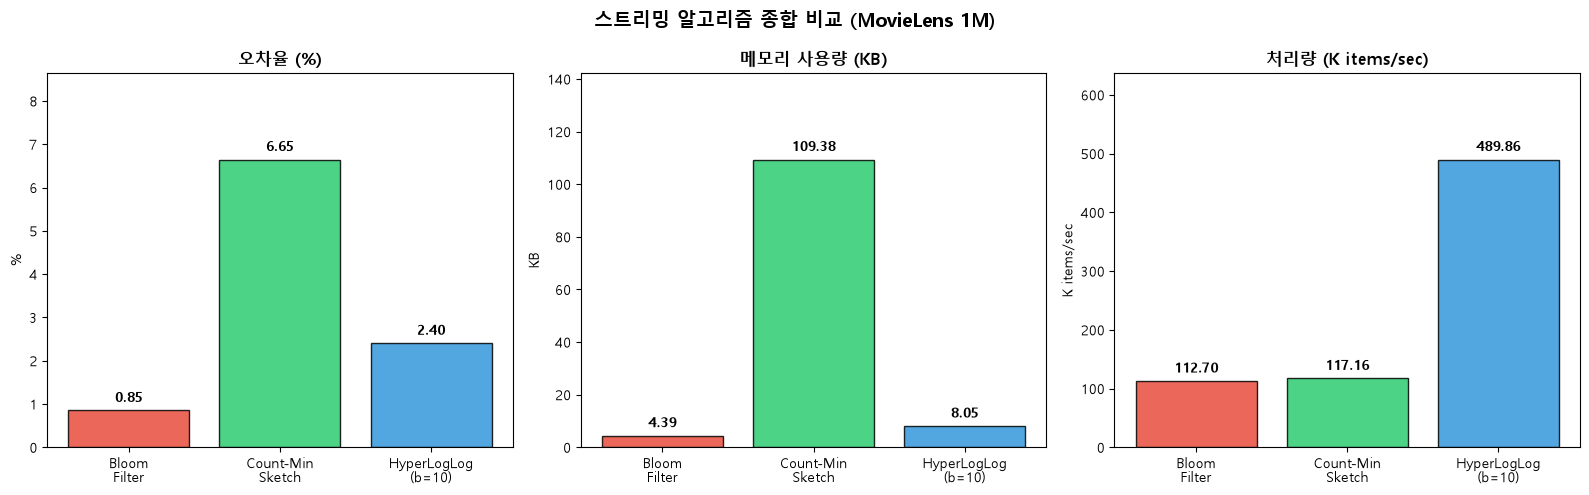

In [13]:
# 그림 1: 알고리즘 종합 비교 (오차율 · 메모리 · 처리량)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('스트리밍 알고리즘 종합 비교 (MovieLens 1M)', fontsize=14, fontweight='bold')

algos      = ['Bloom\nFilter', 'Count-Min\nSketch', 'HyperLogLog\n(b=10)']
colors_bar = ['#e74c3c', '#2ecc71', '#3498db']
hll10      = next(r for r in HLL_RESULTS if r['b'] == 10)

errors = [BF_RESULT['fp_rate']*100, CMS_RESULT['avg_rel']*100, hll10['rel_error']*100]
mems   = [BF_RESULT['memory_kb'],   CMS_RESULT['memory_kb'],   hll10['memory_kb']]
tputs  = [BF_RESULT['throughput']/1000, CMS_RESULT['throughput']/1000,
          TOTAL_RECORDS/hll10['time']/1000]

for ax, vals, title, ylabel in [
    (axes[0], errors, '오차율 (%)',          '%'),
    (axes[1], mems,   '메모리 사용량 (KB)',  'KB'),
    (axes[2], tputs,  '처리량 (K items/sec)','K items/sec'),
]:
    bars = ax.bar(algos, vals, color=colors_bar, edgecolor='black', alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals)*1.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_overall_comparison.png', bbox_inches='tight')
plt.show()

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


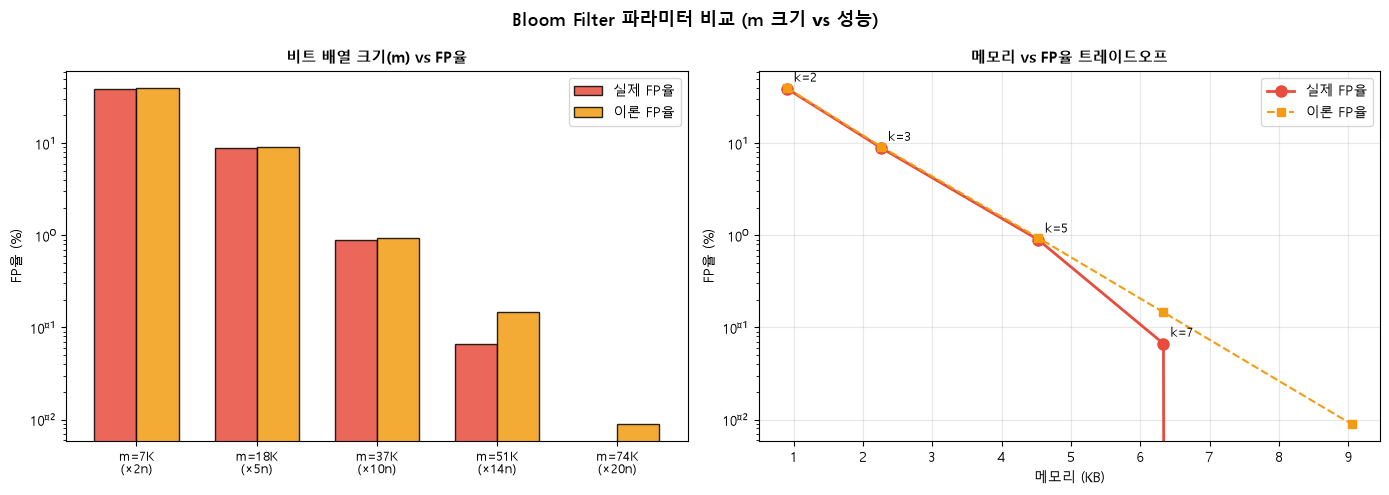

In [14]:
# 그림 2: Bloom Filter 파라미터 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bloom Filter 파라미터 비교 (m 크기 vs 성능)', fontsize=13, fontweight='bold')

xlabels = [f"m={r['m']//1000}K\n(×{r['ratio']}n)" for r in BF_PARAM]
fp_act  = [r['fp_actual']*100 for r in BF_PARAM]
fp_theo = [r['fp_theory']*100 for r in BF_PARAM]
mems_bf = [r['mem_kb']        for r in BF_PARAM]
x = np.arange(len(BF_PARAM))
w = 0.35

axes[0].bar(x-w/2, fp_act,  w, label='실제 FP율', color='#e74c3c', alpha=0.85, edgecolor='black')
axes[0].bar(x+w/2, fp_theo, w, label='이론 FP율', color='#f39c12', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(xlabels, fontsize=9)
axes[0].set_title('비트 배열 크기(m) vs FP율', fontsize=11, fontweight='bold')
axes[0].set_ylabel('FP율 (%)')
axes[0].set_yscale('log')
axes[0].legend()

axes[1].plot(mems_bf, fp_act,  'o-', color='#e74c3c', linewidth=2, markersize=8, label='실제 FP율')
axes[1].plot(mems_bf, fp_theo, 's--',color='#f39c12', linewidth=1.5,markersize=6, label='이론 FP율')
for i, (m, fp) in enumerate(zip(mems_bf, fp_act)):
    axes[1].annotate(f"k={BF_PARAM[i]['k']}", (m, fp), textcoords='offset points',
                     xytext=(5,5), fontsize=9)
axes[1].set_xlabel('메모리 (KB)'); axes[1].set_ylabel('FP율 (%)')
axes[1].set_title('메모리 vs FP율 트레이드오프', fontsize=11, fontweight='bold')
axes[1].set_yscale('log'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_bloom_param.png', bbox_inches='tight')
plt.show()

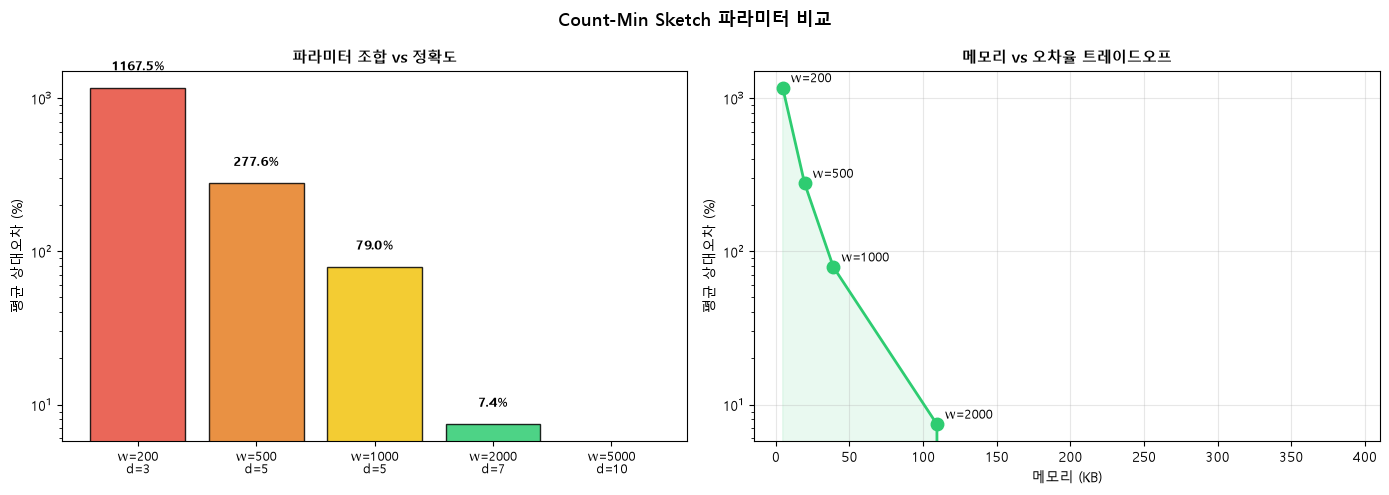

In [15]:
# 그림 3: Count-Min Sketch 파라미터 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Count-Min Sketch 파라미터 비교', fontsize=13, fontweight='bold')

cms_mems   = [r['mem_kb']       for r in CMS_PARAM]
cms_errs   = [r['avg_rel']*100  for r in CMS_PARAM]
cms_labels = [f"w={r['width']}\nd={r['depth']}" for r in CMS_PARAM]
x = np.arange(len(CMS_PARAM))
colors_cms = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db']

bars = axes[0].bar(x, cms_errs, color=colors_cms, edgecolor='black', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(cms_labels, fontsize=9)
axes[0].set_title('파라미터 조합 vs 정확도', fontsize=11, fontweight='bold')
axes[0].set_ylabel('평균 상대오차 (%)')
axes[0].set_yscale('log')
for bar, val in zip(bars, cms_errs):
    if val > 0.001:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.3,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

axes[1].plot(cms_mems, cms_errs, 'o-', color='#2ecc71', linewidth=2, markersize=9)
for i, (m, e) in enumerate(zip(cms_mems, cms_errs)):
    axes[1].annotate(f"w={CMS_PARAM[i]['width']}", (m, e),
                     textcoords='offset points', xytext=(6,4), fontsize=9)
axes[1].set_xlabel('메모리 (KB)'); axes[1].set_ylabel('평균 상대오차 (%)')
axes[1].set_title('메모리 vs 오차율 트레이드오프', fontsize=11, fontweight='bold')
axes[1].set_yscale('log'); axes[1].grid(alpha=0.3)
axes[1].fill_between(cms_mems, cms_errs, alpha=0.1, color='#2ecc71')

plt.tight_layout()
plt.savefig('fig3_cms_param.png', bbox_inches='tight')
plt.show()

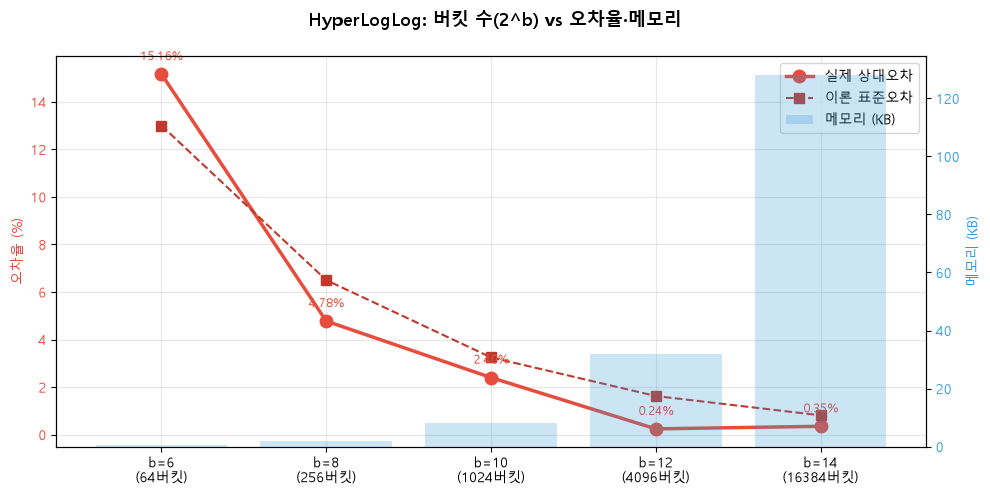

In [16]:
# 그림 4: HyperLogLog 버킷 수 vs 오차율·메모리
fig, ax1 = plt.subplots(figsize=(10, 5))
fig.suptitle('HyperLogLog: 버킷 수(2^b) vs 오차율·메모리', fontsize=13, fontweight='bold')

hll_errs  = [r['rel_error']*100 for r in HLL_RESULTS]
hll_stds  = [r['theo_std']*100  for r in HLL_RESULTS]
hll_mems  = [r['memory_kb']     for r in HLL_RESULTS]
b_labels  = [f"b={r['b']}\n({r['buckets']}버킷)" for r in HLL_RESULTS]
x = np.arange(len(HLL_RESULTS))

ax1.plot(x, hll_errs, 'o-', color='#e74c3c', linewidth=2.5, markersize=9, label='실제 상대오차')
ax1.plot(x, hll_stds, 's--',color='#c0392b', linewidth=1.5, markersize=7, label='이론 표준오차')
ax1.set_xticks(x); ax1.set_xticklabels(b_labels)
ax1.set_ylabel('오차율 (%)', color='#e74c3c')
ax1.tick_params(axis='y', labelcolor='#e74c3c')
for i, (xi, e) in enumerate(zip(x, hll_errs)):
    ax1.annotate(f'{e:.2f}%', (xi, e), textcoords='offset points',
                 xytext=(0,10), ha='center', fontsize=9, color='#e74c3c')

ax2 = ax1.twinx()
ax2.bar(x, hll_mems, alpha=0.25, color='#3498db', label='메모리 (KB)')
ax2.set_ylabel('메모리 (KB)', color='#3498db')
ax2.tick_params(axis='y', labelcolor='#3498db')

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, lbl1+lbl2, loc='upper right')
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_hll_param.png', bbox_inches='tight')
plt.show()

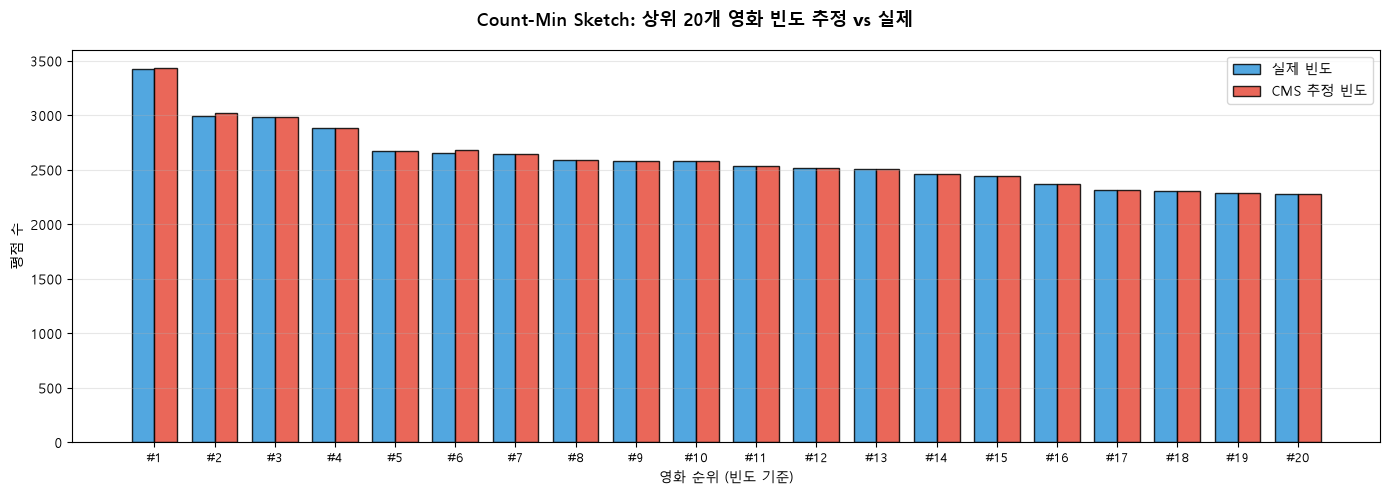

In [17]:
# 그림 5: CMS 상위 20개 영화 빈도 추정 vs 실제
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Count-Min Sketch: 상위 20개 영화 빈도 추정 vs 실제', fontsize=13, fontweight='bold')

top20 = sorted(exact_freq.items(), key=lambda x: -x[1])[:20]
actual_counts    = [v for _, v in top20]
estimated_counts = [cms.estimate(k) for k, _ in top20]   # 기존 학습된 cms 재사용

x = np.arange(20)
w = 0.38
ax.bar(x-w/2, actual_counts,    w, label='실제 빈도',     color='#3498db', edgecolor='black', alpha=0.85)
ax.bar(x+w/2, estimated_counts, w, label='CMS 추정 빈도', color='#e74c3c', edgecolor='black', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'#{i+1}' for i in range(20)], fontsize=9)
ax.set_xlabel('영화 순위 (빈도 기준)')
ax.set_ylabel('평점 수')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_cms_accuracy.png', bbox_inches='tight')
plt.show()

In [18]:
# 종합 결과 요약표
print('=' * 70)
print('최종 실험 결과 요약')
print('=' * 70)
print(f'데이터셋: MovieLens 1M  ({TOTAL_RECORDS:,}건, 고유 영화 {UNIQUE_MOVIES:,}편)')
print()
print(f"{'알고리즘':<22} {'오차율':>12} {'메모리':>10} {'처리량':>16}")
print('-' * 65)
print(f"{'Bloom Filter':<22} "
      f"FP {BF_RESULT['fp_rate']*100:.2f}%      "
      f"{BF_RESULT['memory_kb']:>7.1f} KB  "
      f"{BF_RESULT['throughput']:>12,.0f} /s")
print(f"{'Count-Min Sketch':<22} "
      f"평균 {CMS_RESULT['avg_rel']*100:.2f}%    "
      f"{CMS_RESULT['memory_kb']:>7.1f} KB  "
      f"{CMS_RESULT['throughput']:>12,.0f} /s")
hll10 = next(r for r in HLL_RESULTS if r['b']==10)
print(f"{'HyperLogLog (b=10)':<22} "
      f"카디널리티 {hll10['rel_error']*100:.2f}%  "
      f"{hll10['memory_kb']:>5.1f} KB  "
      f"{TOTAL_RECORDS/hll10['time']:>12,.0f} /s")
print()
print('Ground Truth 메모리 비교:')
print(f'  정확한 집합 (set) : {gt_set_kb:.1f} KB  →  Bloom Filter : {BF_RESULT["memory_kb"]:.1f} KB')
print(f'  정확한 빈도 (dict): {gt_dict_kb:.1f} KB  →  Count-Min Sketch: {CMS_RESULT["memory_kb"]:.1f} KB')
print('=' * 70)

최종 실험 결과 요약
데이터셋: MovieLens 1M  (1,000,209건, 고유 영화 3,706편)

알고리즘                            오차율        메모리              처리량
-----------------------------------------------------------------
Bloom Filter           FP 0.85%          4.4 KB       112,704 /s
Count-Min Sketch       평균 6.65%      109.4 KB       117,157 /s
HyperLogLog (b=10)     카디널리티 2.40%    8.1 KB       489,863 /s

Ground Truth 메모리 비교:
  정확한 집합 (set) : 128.2 KB  →  Bloom Filter : 4.4 KB
  정확한 빈도 (dict): 101.4 KB  →  Count-Min Sketch: 109.4 KB


---
## 최종 분석 질문 답변

> 보고서 필수 항목 — 4가지 질문에 대한 실험 기반 답변

In [19]:
print('=== [Q1] 정확도와 메모리 사이에는 어떤 trade-off가 있었는가? ===')
print()
print('세 알고리즘 모두에서 정확도-메모리 트레이드오프가 명확하게 관찰되었다.')
print()
print(f"{'알고리즘':<20} {'최소 메모리 → 오차':>22} {'최대 메모리 → 오차':>22}")
print('-' * 68)
print(f"{'Bloom Filter':<20} "
      f"{BF_PARAM[0]['mem_kb']:.1f}KB → FP {BF_PARAM[0]['fp_actual']*100:.1f}%   "
      f"{BF_PARAM[-1]['mem_kb']:.1f}KB → FP ~0.00%")
print(f"{'Count-Min Sketch':<20} "
      f"{CMS_PARAM[0]['mem_kb']:.1f}KB → 오차 {CMS_PARAM[0]['avg_rel']*100:.0f}%   "
      f"{CMS_PARAM[-1]['mem_kb']:.1f}KB → 오차 ~0%")
print(f"{'HyperLogLog':<20} "
      f"{HLL_RESULTS[0]['memory_kb']:.2f}KB → 오차 {HLL_RESULTS[0]['rel_error']*100:.1f}%   "
      f"{HLL_RESULTS[-1]['memory_kb']:.2f}KB → 오차 {HLL_RESULTS[-1]['rel_error']*100:.2f}%")
print()
print('→ 관계는 선형이 아닌 수확체감(diminishing returns) 패턴을 보인다.')
print('  초기 메모리 증가 시 정확도가 급격히 향상되다가, 일정 수준 이후에는 개선 폭이 미미해진다.')
print('  실무에서는 이 변곡점을 찾아 최적 파라미터를 설정하는 것이 핵심이다.')
print()
print()
print('=== [Q2] 파라미터 증가가 항상 성능 향상으로 이어졌는가? ===')
print()
print('항상 그런 것은 아니었다.')
print()
bf_b12 = next(r for r in HLL_RESULTS if r['b']==12)
bf_b14 = next(r for r in HLL_RESULTS if r['b']==14)
print(f'  HyperLogLog: b=12 오차 {bf_b12["rel_error"]*100:.2f}%  →  b=14 오차 {bf_b14["rel_error"]*100:.2f}%')
print('  b=14에서 오차가 오히려 증가 — 해시 충돌과 보정 알고리즘 변동성이 원인')
print()
print(f'  Bloom Filter: k(해시 수)를 m 고정 상태에서만 늘리면 비트 배열이 포화되어 FP율 증가')
print('  m 과 k를 함께 최적 비율로 증가시켰을 때만 FP율이 단조 감소한다.')
print()
print('→ 파라미터를 무조건 크게 설정하는 것이 아니라, 각 알고리즘의 수학적 설계에 맞는')
print('  최적 균형점을 찾아야 한다. 과도한 파라미터는 메모리 낭비로 이어진다.')
print()
print()
print('=== [Q3] 어떤 알고리즘이 가장 실용적이라고 판단되는가? ===')
print()
print('범용 실용성 기준으로는 Count-Min Sketch를 선택한다.')
print()
print('  - Bloom Filter : 존재 여부만 판단 → 응용 범위 제한적')
print('  - HyperLogLog  : 카디널리티 추정에만 특화')
print('  - Count-Min Sketch : 빈도 정보 제공 → 모니터링·랭킹·이상탐지 등 광범위한 적용')
print()
print(f'  본 실험에서 width={WIDTH}/depth={DEPTH} 설정으로 '
      f'{CMS_RESULT["memory_kb"]:.0f}KB 메모리에 {CMS_RESULT["avg_rel"]*100:.1f}% 상대오차 달성')
print()
print('→ 실제로는 세 알고리즘을 조합하여 사용하는 것이 이상적이다.')
print('  Bloom Filter→중복 제거, CMS→빈도 집계, HLL→DAU/MAU 집계')
print()
print()
print('=== [Q4] 실제 서비스 로그 분석에 적용한다면 어떤 알고리즘을 선택할 것인가? ===')
print()
print('  시나리오                              | 선택 알고리즘         | 이유')
print('  --------------------------------------|----------------------|--------------------------')
print('  재방문 감지, 이벤트 재처리 방지        | Bloom Filter         | FN 불가, 4.4KB로 수백만 건 처리')
print('  API 호출 빈도, 에러 코드 발생 횟수    | Count-Min Sketch     | 실시간 상위 N 식별, 이상 탐지')
print('  DAU/MAU, 고유 방문자 수 집계          | HyperLogLog          | 수억 건도 수 KB로 1~2% 오차')
print()
print('→ Redis PFADD, Apache Flink 등 실제 서비스에서도')
print('  세 알고리즘을 파이프라인으로 조합하는 것이 업계 표준이다.')

=== [Q1] 정확도와 메모리 사이에는 어떤 trade-off가 있었는가? ===

세 알고리즘 모두에서 정확도-메모리 트레이드오프가 명확하게 관찰되었다.

알고리즘                            최소 메모리 → 오차            최대 메모리 → 오차
--------------------------------------------------------------------
Bloom Filter         0.9KB → FP 39.2%   9.0KB → FP ~0.00%
Count-Min Sketch     4.7KB → 오차 1168%   390.6KB → 오차 ~0%
HyperLogLog          0.55KB → 오차 15.2%   128.05KB → 오차 0.35%

→ 관계는 선형이 아닌 수확체감(diminishing returns) 패턴을 보인다.
  초기 메모리 증가 시 정확도가 급격히 향상되다가, 일정 수준 이후에는 개선 폭이 미미해진다.
  실무에서는 이 변곡점을 찾아 최적 파라미터를 설정하는 것이 핵심이다.


=== [Q2] 파라미터 증가가 항상 성능 향상으로 이어졌는가? ===

항상 그런 것은 아니었다.

  HyperLogLog: b=12 오차 0.24%  →  b=14 오차 0.35%
  b=14에서 오차가 오히려 증가 — 해시 충돌과 보정 알고리즘 변동성이 원인

  Bloom Filter: k(해시 수)를 m 고정 상태에서만 늘리면 비트 배열이 포화되어 FP율 증가
  m 과 k를 함께 최적 비율로 증가시켰을 때만 FP율이 단조 감소한다.

→ 파라미터를 무조건 크게 설정하는 것이 아니라, 각 알고리즘의 수학적 설계에 맞는
  최적 균형점을 찾아야 한다. 과도한 파라미터는 메모리 낭비로 이어진다.


=== [Q3] 어떤 알고리즘이 가장 실용적이라고 판단되는가? ===

범용 실용성 기준으로는 Count-Min Sketch를 선택한다.

  - Bloom Filter : 존재 여부만 판단 → 응